In [4]:
# importuri
%pip install minisom

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from minisom import MiniSom

In [7]:
### TASK 1

# citirea dataseturilor + nume de coloane

iris = pd.read_csv("iris.csv", header=None)
smile = pd.read_csv("smile.csv", header=None)
order = pd.read_csv("order2-3clust.csv", header=None)

square = pd.read_csv("square.data", sep=r"\s+", header=None)
long_data = pd.read_csv("long.data", sep=r"\s+", header=None)


# citire speciala pentru 2d-10c
rows = []
with open("2d-10c.dat", "r") as f:
    lines = f.readlines()

for line in lines[1:]:  # sarim peste primul rand (metadata)
    parts = line.strip().split()

    if len(parts) == 2:
        x, y = parts
        label = np.nan
    elif len(parts) == 3:
        x, y, label = parts
    else:
        continue

    rows.append([float(x), float(y), label])

data_2d_10c = pd.DataFrame(rows, columns=["x", "y", "label"])

iris.columns = ["f1", "f2", "f3", "f4", "label"]
smile.columns = ["x", "y", "label"]
order.columns = ["x", "y", "label"]
square.columns = ["x", "y", "label"]
long_data.columns = ["x", "y", "label"]

In [8]:
# verificare dataseturi

print("IRIS:")
display(iris.head())
print("Columns:", iris.columns)
print()

print("2D-10C:")
display(data_2d_10c.head())
print("Shape:", data_2d_10c.shape)
print()

print("SMILE:")
display(smile.head())
print("Columns:", smile.columns)
print()

print("ORDER:")
display(order.head())
print("Columns:", order.columns)
print()

print("SQUARE:")
display(square.head())
print("Shape:", square.shape)
print()

print("LONG:")
display(long_data.head())
print("Shape:", long_data.shape)

IRIS:


,f1,f2,f3,f4,label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Columns: Index(['f1', 'f2', 'f3', 'f4', 'label'], dtype='object')

2D-10C:


,x,y,label
0,-22.277800,-10.87390,NaN
1,19.002100,11.99040,NaN
2,12.757900,-4.81962,0
3,-0.298175,-5.03868,0
4,9.155580,-3.81778,0


Shape: (2527, 3)

SMILE:


...

Columns: Index(['x', 'y', 'label'], dtype='object')

SQUARE:


,x,y,label
0,6.10273,6.28359,0
1,5.46167,8.29113,0
2,6.50055,4.81082,0
3,5.00059,9.02367,0
4,3.66494,11.85230,0


Shape: (1000, 3)

LONG:


,x,y,label
0,0.167967,-0.171240,0
1,-1.257550,0.054219,0
2,1.648140,0.027165,0
3,-0.124180,0.038627,0
4,2.458720,-0.039070,0


Shape: (1000, 3)


In [10]:
# curățare + tipuri corecte

# eliminăm punctele fără label din 2d-10c
data_2d_10c = data_2d_10c.dropna().reset_index(drop=True)

# transformăm labelurile în int (important pt ARI)
iris["label"] = iris["label"].astype(int)
smile["label"] = smile["label"].astype(int)
order["label"] = order["label"].astype(int)
square["label"] = square["label"].astype(int)
long_data["label"] = long_data["label"].astype(int)
data_2d_10c["label"] = data_2d_10c["label"].astype(int)

In [11]:
# separare X și y

datasets = {
    "iris": iris,
    "2d-10c": data_2d_10c,
    "smile": smile,
    "order": order,
    "square": square,
    "long": long_data
}

prepared_data = {}

for name, df in datasets.items():
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    prepared_data[name] = {"X": X, "y": y}

for name, data in prepared_data.items():
    print(name, "-> X:", data["X"].shape, "| y:", data["y"].shape)

iris -> X: (150, 4) | y: (150,)
2d-10c -> X: (2525, 2) | y: (2525,)
smile -> X: (400, 2) | y: (400,)
order -> X: (300, 2) | y: (300,)
square -> X: (1000, 2) | y: (1000,)
long -> X: (1000, 2) | y: (1000,)


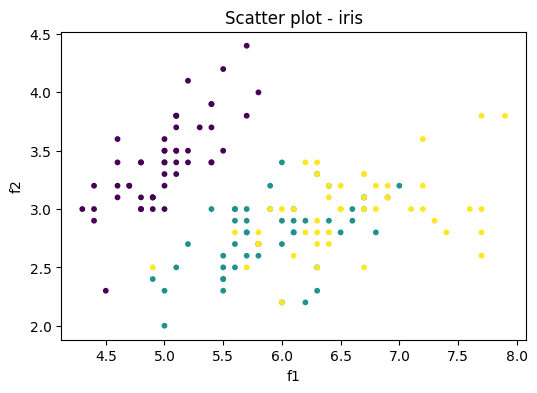

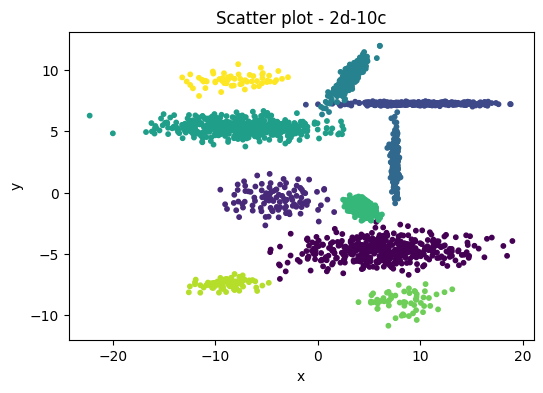

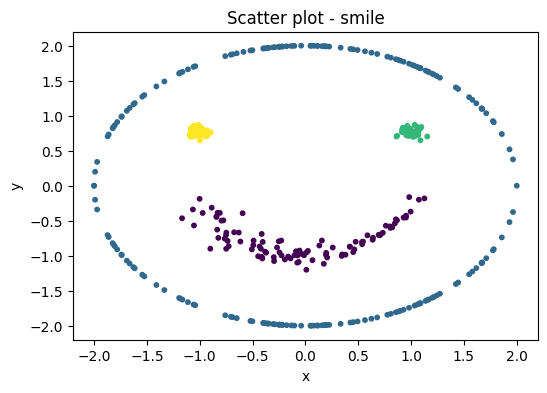

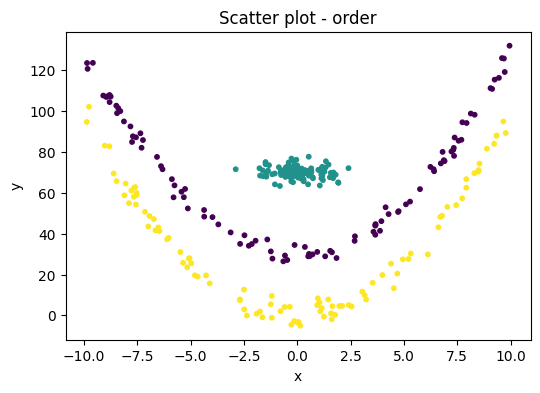

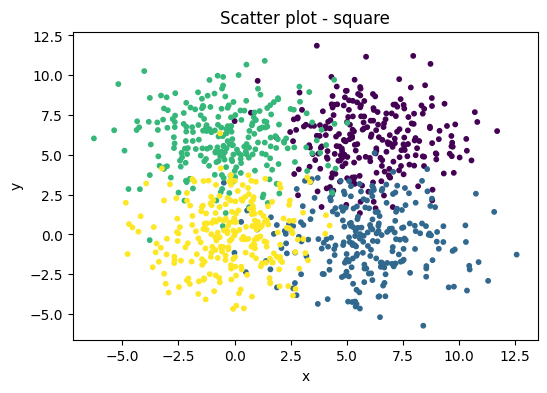

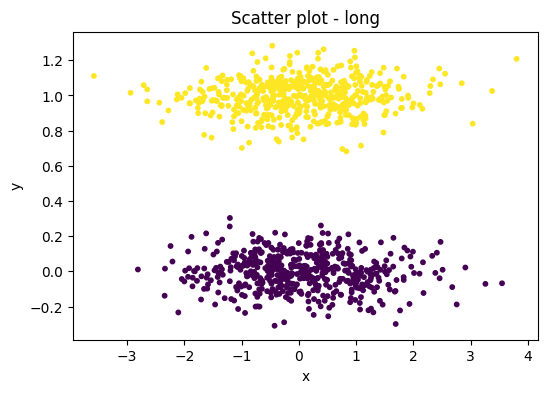

In [12]:
# Scatter plots

for name, data in prepared_data.items():
    X = data["X"]
    y = data["y"]

    plt.figure(figsize=(6, 4))

    if X.shape[1] == 2:
        # dataseturi 2D (majoritatea)
        plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
        plt.xlabel("x")
        plt.ylabel("y")
    else:
        # iris (4D) -> folosim primele 2 feature-uri pentru vizualizare
        plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
        plt.xlabel("f1")
        plt.ylabel("f2")

    plt.title(f"Scatter plot - {name}")
    plt.show()

The datasets were visualized using scatter plots. Some datasets (e.g., iris) show well-separated clusters, while others (e.g., smile) exhibit non-convex shapes, which may affect clustering performance.

In [13]:
### KMEANS

kmeans_results = {}

for name, data in prepared_data.items():
    X = data["X"]
    y = data["y"]

    # numărul real de clase
    k = len(np.unique(y))

    # K-Means
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_pred = model.fit_predict(X)

    # ARI
    ari = adjusted_rand_score(y, y_pred)

    kmeans_results[name] = ari

    print(f"{name} -> k={k}, ARI={ari:.4f}")

iris -> k=3, ARI=0.7302
2d-10c -> k=10, ARI=0.7240
smile -> k=4, ARI=0.1852
order -> k=3, ARI=0.2422
square -> k=4, ARI=0.6909
long -> k=2, ARI=-0.0008


In [14]:
### EM

em_results = {}

for name, data in prepared_data.items():
    X = data["X"]
    y = data["y"]

    k = len(np.unique(y))

    model = GaussianMixture(n_components=k, random_state=42)
    y_pred = model.fit_predict(X)

    ari = adjusted_rand_score(y, y_pred)

    em_results[name] = ari

    print(f"{name} -> k={k}, ARI={ari:.4f}")

iris -> k=3, ARI=0.9039
2d-10c -> k=10, ARI=0.9982
smile -> k=4, ARI=0.1923
order -> k=3, ARI=0.3809
square -> k=4, ARI=0.6822
long -> k=2, ARI=0.0149


In [16]:
### SOM


som_results = {}

for name, data in prepared_data.items():
    X = data["X"]
    y = data["y"]

    # normalizare (IMPORTANT pentru SOM)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    k = len(np.unique(y))

    # grid SOM (simplu: k neuroni într-o linie)
    som = MiniSom(x=k, y=1, input_len=X.shape[1], sigma=1.0, learning_rate=0.5)

    som.random_weights_init(X_scaled)
    som.train_random(X_scaled, 1000)

    # atribuim fiecare punct la neuron
    winners = np.array([som.winner(x)[0] for x in X_scaled])

    # ARI
    ari = adjusted_rand_score(y, winners)

    som_results[name] = ari

    print(f"{name} -> k={k}, ARI={ari:.4f}")

iris -> k=3, ARI=0.6211
2d-10c -> k=10, ARI=0.5199
smile -> k=4, ARI=0.1900
order -> k=3, ARI=0.2865
square -> k=4, ARI=0.5625
long -> k=2, ARI=1.0000


## Clustering Performance Comparison

| Dataset | K-Means  | EM       | SOM      | Best    |
| ------- | -------- | -------- | -------- | ------- |
| iris    | 0.73     | **0.90** | 0.62     | **EM**  |
| 2d-10c  | 0.72     | **0.99** | 0.52     | **EM**  |
| smile   | 0.18     | 0.19     | 0.19     | niciuna |
| order   | 0.24     | **0.38** | 0.29     | **EM**  |
| square  | **0.69** | 0.68     | 0.56     | K-Means |
| long    | ~0       | ~0.01    | **1.00** | SOM     |


The three clustering algorithms (K-Means, EM, and SOM) were evaluated using the Adjusted Rand Index (ARI).

-> The EM (Gaussian Mixture) algorithm achieved the best performance on most datasets (iris, 2d-10c, order), suggesting that it can better model clusters with different shapes and distributions.

-> K-Means performed well on datasets with more regular, spherical cluster structures (e.g., square), but struggled with more complex shapes.

-> SOM showed mixed results. It performed poorly on most datasets, but achieved a perfect score on the long dataset, likely due to the linear structure of the data.

Datasets such as smile and long highlight the limitations of traditional clustering methods, as their non-convex shapes are not well captured by K-Means or EM.

Overall, EM proved to be the most robust method across datasets, while K-Means was effective only in simpler cases, and SOM showed inconsistent behavior.

In [17]:
### TASK 2

# pregătim doar cele 2 dataseturi

task2_data = {
    "iris": prepared_data["iris"]["X"],
    "2d-10c": prepared_data["2d-10c"]["X"]
}

for name, X in task2_data.items():
    print(name, X.shape)

iris (150, 4)
2d-10c (2525, 2)


In [18]:
# calcul silhouette și inertia pentru mai multe valori de k
task2_results = {}

for name, X in task2_data.items():
    silhouette_scores = []
    inertias = []
    k_values = range(2, 11)

    for k in k_values:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X)

        sil = silhouette_score(X, labels)
        inertia = model.inertia_

        silhouette_scores.append(sil)
        inertias.append(inertia)

    task2_results[name] = {
        "k_values": list(k_values),
        "silhouette_scores": silhouette_scores,
        "inertias": inertias
    }

    print(f"{name} done")

iris done
2d-10c done


In [19]:
# afisam valorile numerice

for name, results in task2_results.items():
    print(f"\n{name.upper()}")
    print("k | silhouette | inertia")
    for k, sil, iner in zip(results["k_values"], results["silhouette_scores"], results["inertias"]):
        print(f"{k} | {sil:.4f} | {iner:.4f}")


IRIS
k | silhouette | inertia
2 | 0.6808 | 152.3687
3 | 0.5526 | 78.9408
4 | 0.4978 | 57.3179
5 | 0.4885 | 46.5356
6 | 0.3682 | 38.9310
7 | 0.3548 | 34.3602
8 | 0.3521 | 30.0234
9 | 0.3434 | 28.1455
10 | 0.3186 | 25.9515

2D-10C
k | silhouette | inertia
2 | 0.4857 | 101128.7554
3 | 0.5284 | 54829.9861
4 | 0.5258 | 42232.2114
5 | 0.5231 | 32354.8220
6 | 0.5139 | 24757.3665
7 | 0.4989 | 20398.4896
8 | 0.5227 | 16565.1750
9 | 0.5405 | 13756.5900
10 | 0.5518 | 11919.2192


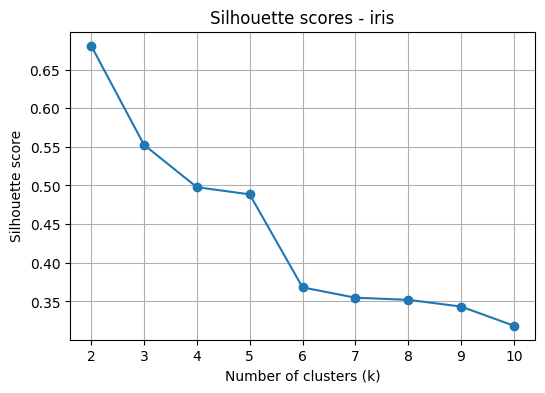

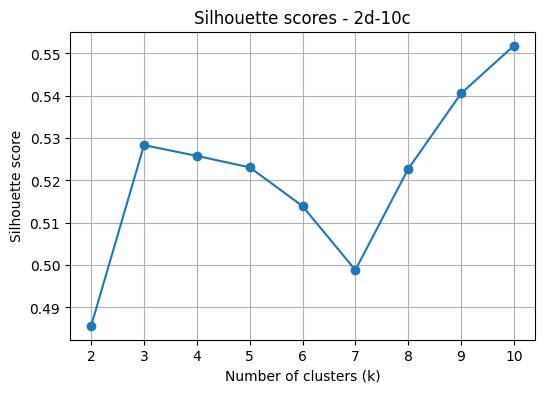

In [20]:
# plot pt silhouette

for name, results in task2_results.items():
    plt.figure(figsize=(6, 4))
    plt.plot(results["k_values"], results["silhouette_scores"], marker="o")
    plt.title(f"Silhouette scores - {name}")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette score")
    plt.grid(True)
    plt.show()

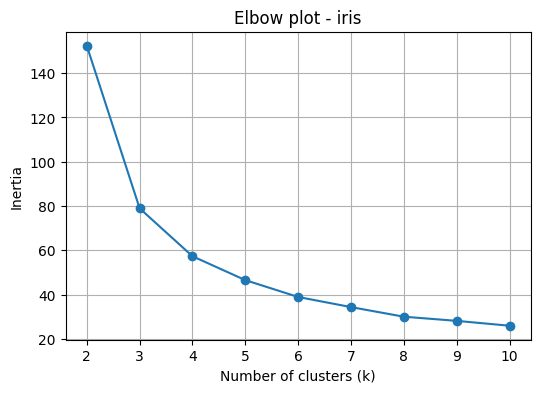

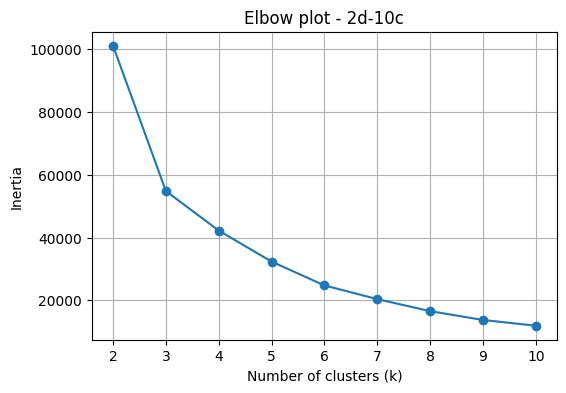

In [21]:
# elbow plots

for name, results in task2_results.items():
    plt.figure(figsize=(6, 4))
    plt.plot(results["k_values"], results["inertias"], marker="o")
    plt.title(f"Elbow plot - {name}")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.grid(True)
    plt.show()

### Automatic Selection of Number of Clusters

The optimal number of clusters was determined using both the Silhouette score and the Elbow method.

For the iris dataset, the highest Silhouette score was obtained for k=2. However, the Elbow plot suggests a clear inflection point at k=3, and considering the known structure of the dataset, the optimal number of clusters was selected as 3.

For the 2d-10c dataset, the Silhouette score increases with k and reaches its maximum at k=10. The Elbow plot does not show a sharp bend, but the continuous decrease in inertia supports the selection of a higher number of clusters. Therefore, the optimal number of clusters was determined to be 10, which also matches the true number of clusters.

Overall, combining both methods provides a more reliable estimate than using either method alone